# Newsfeed & Student Engagement: An A/B Test Analysis

In this notebook we will analyze the activity logs collected from an educational platform. We will try to answer the following question: does exposure to a public Newsfeed create peer pressure, encouraging students to start working on assignments earlier?

In [1]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)

numpy        2.5.3
pandas       3.0.6


In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")

## Understanding the data

Two tables matter here — `checker` (lab submission logs) and `pageviews` (Newsfeed visit logs).

In [3]:
pd.read_sql("SELECT * FROM checker LIMIT 5", conn)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,NaN,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1
2,2,checking,0,2020-04-16 21:46:47.769088,7,NaN,admin_1
3,3,ready,0,2020-04-16 21:46:48.121217,7,lab02,admin_1
4,4,checking,0,2020-04-16 21:53:01.862637,6,code_rvw,admin_1


In [4]:
pd.read_sql("SELECT * FROM pageviews LIMIT 5", conn)

,index,uid,datetime
0,0,admin_1,2020-04-17 12:01:08.463179
1,1,admin_1,2020-04-17 12:01:23.743946
2,2,admin_3,2020-04-17 12:17:39.287778
3,3,admin_3,2020-04-17 12:17:40.001768
4,4,admin_1,2020-04-17 12:27:30.646665


## Building the Datamart

To test the hypothesis, we need one row per user showing when they first 
submitted a lab and when they first viewed the Newsfeed.

We only count a submission once it's finished being checked (`status='ready'`) 
and only the first attempt (`numTrials=1`), since that marks when a student 
actually started the lab. We also restrict this to the labs active during 
the experiment period (`laba04`, `laba04s`, `laba05`, `laba06`, `laba06s`, 
`project1`), and to student accounts only (`user_*`, excluding admins).

In [5]:
query = """
SELECT
    checker.uid,
    checker.labname,
    checker.timestamp AS first_commit_ts,
    MIN(pageviews.datetime) AS first_view_ts
FROM checker
LEFT JOIN pageviews
ON checker.uid = pageviews.uid
WHERE checker.uid LIKE 'user_%'
    AND checker.status = 'ready'
    AND checker.numTrials = 1 
    AND checker.labname IN ('laba04', 'laba04s', 'laba05', 'laba06', 'laba06s', 'project1')  
GROUP BY checker.uid, checker.labname
"""

datamart = pd.read_sql(query, conn, parse_dates=["first_commit_ts", "first_view_ts"])
datamart

,uid,labname,first_commit_ts,first_view_ts
0,user_1,laba04,2020-04-26 17:06:18.462708,2020-04-26 21:53:59.624136
1,user_1,laba04s,2020-04-26 17:12:11.843671,2020-04-26 21:53:59.624136
2,user_1,laba05,2020-05-02 19:15:18.540185,2020-04-26 21:53:59.624136
3,user_1,laba06,2020-05-17 16:26:35.268534,2020-04-26 21:53:59.624136
4,user_1,laba06s,2020-05-20 12:23:37.289724,2020-04-26 21:53:59.624136
...,...,...,...,...
135,user_8,laba04s,2020-04-19 10:22:35.761944,NaT
136,user_8,laba05,2020-05-02 13:28:07.705193,NaT
137,user_8,laba06,2020-05-16 17:56:15.755553,NaT
138,user_8,laba06s,2020-05-16 20:01:07.900727,NaT


### Splitting into test and control groups

Users who visited the Newsfeed at least once form the `test` group; those 
who never did form the `control` group. The `control` group's `first_view_ts` 
is missing by definition, since they have no view to record.

In [6]:
test = datamart[datamart['first_view_ts'].notna()].copy()

In [7]:
control = datamart[datamart['first_view_ts'].isna()].copy()

### Handling missing values in the control group

To later compare behavior "before" and "after" the Newsfeed for the control 
group too, we need some reference timestamp to split on, even though these 
users never actually viewed the page. We fill their missing `first_view_ts` 
with the average `first_view_ts` from the test group.

This is an approximation, not a real behavioral event, and is a limitation 
of this analysis: it assumes control users' behavior wasn't already changing 
around that time for unrelated reasons.

In [8]:
avg = test['first_view_ts'].mean()
control['first_view_ts'] = control['first_view_ts'].fillna(avg)
control.head()

,uid,labname,first_commit_ts,first_view_ts
12,user_11,laba05,2020-05-03 21:06:55.970293,2020-04-27 00:40:05.761783
13,user_11,project1,2020-05-03 23:45:33.673409,2020-04-27 00:40:05.761783
14,user_12,laba04,2020-04-18 17:07:51.767358,2020-04-27 00:40:05.761783
15,user_12,laba04s,2020-04-26 15:42:38.070593,2020-04-27 00:40:05.761783
16,user_12,laba05,2020-05-03 08:39:25.174316,2020-04-27 00:40:05.761783


## A/B Test: Does the Newsfeed Change Behavior?

We now test the core hypothesis: does viewing the Newsfeed shift how early 
students start their labs? For each group (test and control), we compare 
the average gap between first commit and deadline *before* vs. *after* 
their (real or imputed) first Newsfeed view. If the shift is clear in the 
test group but not in the control group, that's evidence the Newsfeed 
itself caused the change — not just the passage of time.

In [9]:
# load lab deadlines, needed to compute the commit-deadline gap
deadlines = pd.read_sql("""SELECT * FROM deadlines""", conn, parse_dates=["deadlines"])

Both groups need the same before/after transformation — we define it once and reuse it

In [10]:
def compute_before_after(df, deadlines):
    # attach each lab's deadline to the corresponding commit
    df = df.merge(deadlines, how='left', left_on='labname', right_on='labs')

    # hours between first commit and the deadline
    df['diff'] = (df['first_commit_ts'] - df['deadlines']) / pd.Timedelta('1h')
    # was this commit before or after the user's first Newsfeed view?
    df['time'] = np.where(df['first_commit_ts'] < df['first_view_ts'], 'before', 'after')
    
    # exclude project1 (longer deadline, treated as an outlier)
    df = df[df['labname'].isin(['laba04', 'laba04s', 'laba05', 'laba06', 'laba06s'])]
    df = df[['uid', 'time', 'diff']]

    # only keep users who have both a before and an after observation
    df = df.groupby('uid').filter(lambda group: group['time'].nunique() > 1)
    
    # average per user
    df = df.groupby(['uid', 'time'])['diff'].mean().reset_index()

    return df

def compute_avg(df, deadlines):
    df = compute_before_after(df, deadlines)
    # average across users, split by before/after
    df = df.groupby('time')['diff'].mean()

    return df

### Test group: before vs. after

In [11]:
test_results = compute_avg(test, deadlines)

In [12]:
test_results

time
after    -100.178032
before    -66.679398
Name: diff, dtype: float64

### Control group: before vs. after

We use each control user's imputed reference timestamp as their "before/after" 
split point, since they have no real Newsfeed view to split on.

In [13]:
control_results = compute_avg(control, deadlines)

In [14]:
control_results

time
after    -99.803422
before   -98.467698
Name: diff, dtype: float64

### Interpretation

The pattern supports the hypothesis: test group users showed a large shift 
in behavior (-66.7 → -100.2 hours, about 33.5 hours earlier relative to the 
deadline) after their first Newsfeed view, while the control group showed 
almost no shift (-98.5 → -99.8 hours, about 1.3 hours). This difference in 
magnitude — a strong effect in test, essentially none in control — is 
consistent with the Newsfeed causing students to start labs earlier.

That said, this isn't conclusive. The two groups start from noticeably 
different baselines (-66.7 vs. -98.5 hours), which may partly reflect the 
artificial reference timestamp used for the control group, or may reflect 
underlying differences between users who chose to visit the Newsfeed and 
those who didn't — since assignment to test/control wasn't random. No formal 
significance test was run to confirm the shift is unlikely to be due to 
chance. So while the data is consistent with the hypothesis, it stops short 
of proving it.

## Visual Analysis

The A/B test suggests the Newsfeed shifts behavior, but averages can hide a lot: outliers, high variance, or non-linear patterns a single number would miss. The next two visuals check the result from those angles.

### Distribution Check: Boxplots

In [15]:
test_visualization = compute_before_after(test, deadlines)

In [16]:
control_visualization = compute_before_after(control, deadlines)

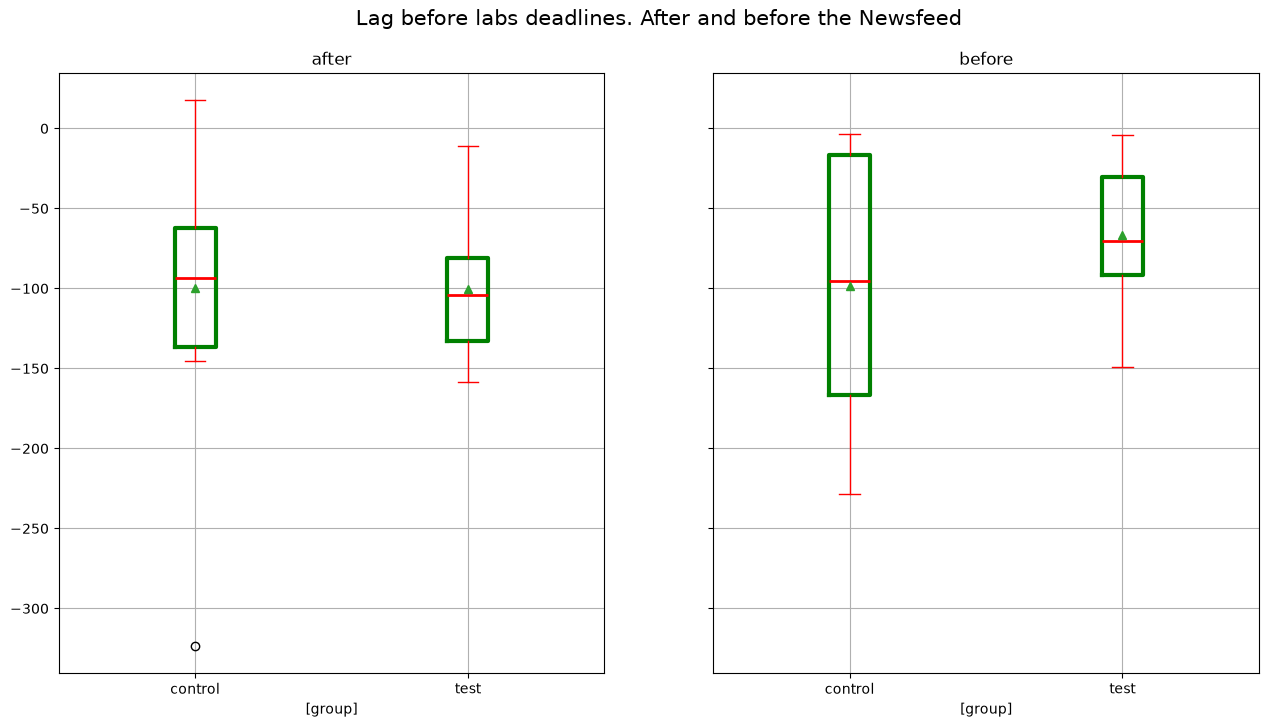

In [17]:
test_visualization['group'] = 'test'
control_visualization['group'] = 'control'
df_combined = pd.concat([test_visualization, control_visualization], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=True)

for ax, period in zip(axes, ['after', 'before']):
    subset = df_combined[df_combined['time'] == period]
    # Create a boxplot for the 'diff' with a box for each group
    subset.boxplot(column='diff', by='group', ax=ax,
                    boxprops=dict(linewidth=3, color='green'),
                    medianprops=dict(linewidth=2, color='red'),
                    whiskerprops=dict(color='red'),
                    capprops=dict(color='red'),
                    showmeans=True)
    ax.set_title(period)
    ax.set_xlabel('[group]')

fig.suptitle("Lag before labs deadlines. After and before the Newsfeed", fontsize=15)
plt.show()

The A/B comparison earlier showed a large shift in the test group's average 
(before vs. after), while the control group's average barely moved. This 
boxplot complicates that "no change in control" story: while control's 
median stayed roughly flat, its variance shrank substantially - its box 
went from very wide (before) to much narrower (after). That's a real 
behavioral change the mean alone doesn't capture. There's also a single 
outlier in control's "after" group (around -325 hours), suggesting at 
least one user started a lab unusually early relative to the deadline.

Combined with the baseline difference noted earlier (control started from 
a lower, more spread-out position than test), this adds to the case that 
test and control users may not be directly comparable: the two groups 
seem to differ in more than just their response to the Newsfeed.

### Correlation Check: Scatter Matrix

Beyond the before/after comparison, we can also ask: does *how much* a 
student uses the Newsfeed relate to how early they start their labs? A 
simple way to check is a correlation coefficient between the number of 
pageviews and the commit-deadline gap. However, correlation coefficients 
only capture *linear* relationships - if the real pattern is more complex, 
this number alone could be misleading. We'll compute it first, then use a 
scatter matrix to check visually whether anything a plain number might miss 
is actually going on.

In [18]:
pageviews = pd.read_sql("SELECT * FROM pageviews", conn, index_col="index", parse_dates=["datetime"])
checker = pd.read_sql("SELECT * FROM checker", conn, index_col="index", parse_dates=["datetime"])

In [19]:
commits_count = (
    checker
    .loc[checker['uid'].str.contains('^user', na=False)]
    .query("labname in ['laba04', 'laba04s', 'laba05', 'laba06', 'laba06s'] and status == 'ready'")
    .assign(num_commits = lambda x: x.groupby('uid')['labname'].transform('count'))
    [['uid', 'num_commits']]
    .drop_duplicates()
    .reset_index(drop=True)
)

In [20]:
views_diff = (
    test
    .merge(deadlines, how='left', left_on='labname', right_on='labs')
    .merge(pageviews, how='left', on='uid')
    .merge(commits_count, how='left', on='uid')
    .query("labname in ['laba04', 'laba04s', 'laba05', 'laba06', 'laba06s']")
    .assign(
        avg_diff=lambda df: (df['first_commit_ts'] - df['deadlines']) / pd.Timedelta('1h'),
        pageviews=lambda df: df.groupby('uid')['datetime'].transform('nunique')
    )
    .drop_duplicates()
    .groupby(['uid', 'pageviews', 'num_commits'], as_index=False)['avg_diff']
    .mean()
)

In [21]:
views_diff[['pageviews', 'avg_diff']].corr()

,pageviews,avg_diff
pageviews,1.000000,-0.279143
avg_diff,-0.279143,1.000000


The correlation coefficient is -0.28 — a weak negative relationship, 
suggesting more Newsfeed visits are loosely associated with starting labs 
earlier, but the relationship is far from strong. On its own, this number 
doesn't tell us much; let's check visually whether a clearer, possibly 
non-linear pattern is hiding underneath.

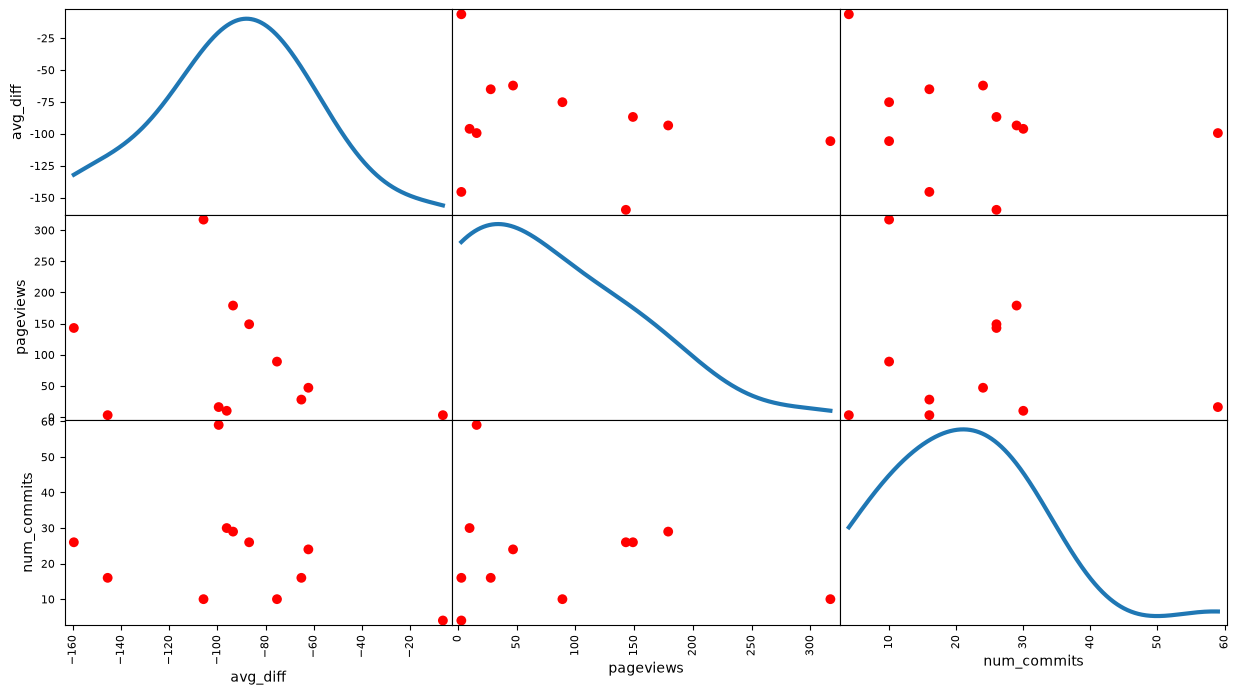

In [22]:
axes = scatter_matrix(views_diff[['avg_diff', 'pageviews', 'num_commits']],
                        alpha=1.0, 
                        figsize=(15, 8), s=200,
                        diagonal='kde', color='red')

for ax in axes.flatten():
    for line in ax.get_lines():
        line.set_linewidth(3)

plt.show()

The scatter matrix confirms the earlier finding: there's no visible pattern 
between pageviews and avg_diff, in either direction — the weak correlation 
coefficient wasn't hiding a more complex relationship, it genuinely 
reflects a lack of connection between how often a user checks the Newsfeed 
and how early they start their labs. The same holds for pageviews and 
num_commits: no relationship is visible there either.

The diagonal distributions add some texture: num_commits is right-skewed 
(most users make relatively few commits, a handful make many), while 
avg_diff is roughly symmetric, centered around -100 to -130 hours — meaning 
most students, regardless of group, tend to start labs well before the 
deadline rather than at the last minute.

## Conclusion

## Limitations & Next Steps